# 二阶龙格-库塔法（RK2）求解自由落体运动

- [周详](xiangzhou@whu.edu.cn)
- 武汉大学
- 2026年9月22日

前向欧拉法求解自由落体时：速度精确，位置每步滞后 $\tfrac{1}{2}g h^2$、误差随 $t$ 线性增长，总机械能随 $t$ 无界漂移——这些缺陷都源于位置更新只用了**区间左端的速度**。本例换一种思路——在区间的**中点**再估一次斜率——得到二阶龙格-库塔法（RK2，中点形式）。

自由落体的运动方程与解析解（取竖直向下为正）：

$$
\frac{dx}{dt} = v, \qquad \frac{dv}{dt} = g, \qquad
v(t) = v_0 + g\,t, \qquad x(t) = x_0 + v_0\,t + \tfrac{1}{2} g\,t^2
$$

**RK2（中点形式）**：先用欧拉法走**半步**到中点，估出中点处的斜率，再用它走整步。对状态 $\boldsymbol y = (x, v)$：

$$
\boldsymbol k_1 = \boldsymbol f(\boldsymbol y_n), \qquad
\boldsymbol k_2 = \boldsymbol f\!\left(\boldsymbol y_n + \tfrac{h}{2}\boldsymbol k_1\right), \qquad
\boldsymbol y_{n+1} = \boldsymbol y_n + h\,\boldsymbol k_2
$$

每步需计算**两次**右端（欧拉法只算一次）。代入自由落体（$\dot x = v$，$\dot v = g$）后，速度更新与欧拉法相同，只有位置更新改变：

$$
v_{n+\frac{1}{2}} = v_n + \tfrac{h}{2} g \ \ (\text{中点速度}), \qquad
v_{n+1} = v_n + h\,g, \qquad
x_{n+1} = x_n + h\,v_{n+\frac{1}{2}} = x_n + h\,v_n + \tfrac{1}{2} g\,h^2
$$

与欧拉格式相比，位置更新多出了 $\tfrac{1}{2} g h^2$——恰好是匀变速运动位移公式 $x = x_0 + v_0 t + \tfrac{1}{2} g t^2$ 中间的那一项。

**总机械能**仍取 $E = \tfrac{1}{2}mv^2 - mgx$（$x$ 轴向下，取 $x=0$ 处势能为零）。

**运行之前，先把你的预测写下来**：

1. RK2 与欧拉法的速度更新相同吗？两种方法的差别全部集中在哪个变量的更新上？
2. 位置更新多出的 $\tfrac{1}{2} g h^2$ 恰好补上了欧拉缺失的项——猜一猜：RK2 的位置、速度与解析解是什么关系？总机械能守恒吗？
3. 若把步长 $h$ 减半，RK2 的误差变为几分之一？

带着预测运行下面的代码，逐条对照。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 字体配置：按操作系统自动选择中文字体，
# 西文与数学公式用 Times New Roman 风格（STIX）
import platform
system = platform.system()
if system == 'Darwin':
    cn_font = 'Songti SC'
elif system == 'Windows':
    cn_font = 'SimSun'
else:  # Linux
    cn_font = 'Noto Serif CJK SC'

plt.rcParams['font.family'] = [cn_font, 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def forward_euler_free_fall(x0, v0, g, h, n_steps):
    """前向欧拉法求解自由落体 dx/dt = v, dv/dt = g
    返回时间、位置、速度数组（长度 n_steps + 1）"""
    t = np.arange(n_steps + 1) * h
    x = np.empty(n_steps + 1)
    v = np.empty(n_steps + 1)
    x[0], v[0] = x0, v0
    for n in range(n_steps):
        x[n + 1] = x[n] + h * v[n]
        v[n + 1] = v[n] + h * g
    return t, x, v


def rk2_midpoint_free_fall(x0, v0, g, h, n_steps):
    """RK2 中点法求解自由落体 dx/dt = v, dv/dt = g
    先走半步估出中点速度，再用中点斜率走整步"""
    t = np.arange(n_steps + 1) * h
    x = np.empty(n_steps + 1)
    v = np.empty(n_steps + 1)
    x[0], v[0] = x0, v0
    for n in range(n_steps):
        v_mid = v[n] + 0.5 * h * g      # 中点速度（半步欧拉预估）
        x[n + 1] = x[n] + h * v_mid     # 用中点斜率更新位置
        v[n + 1] = v[n] + h * g         # 速度更新与欧拉法相同
    return t, x, v


# 参数（便于与前向欧拉法的结果对照）
x0, v0 = 0.0, 0.0   # 初始位置 (m)、初速度 (m/s)
m = 1.0             # 质量 (kg)
g = 9.8             # 重力加速度 (m/s^2)
h = 0.5             # 时间步长 (s)
t_end = 5.0         # 总时间 (s)
n_steps = int(t_end / h)

t, x_euler, v_euler = forward_euler_free_fall(x0, v0, g, h, n_steps)
t, x_rk2, v_rk2 = rk2_midpoint_free_fall(x0, v0, g, h, n_steps)

x_exact = x0 + v0 * t + 0.5 * g * t**2
v_exact = v0 + g * t

# 总机械能：E = 1/2 m v^2 - m g x（x 轴向下，取 x=0 处势能为零）
E_euler = 0.5 * m * v_euler**2 - m * g * x_euler
E_rk2   = 0.5 * m * v_rk2**2 - m * g * x_rk2
E_exact0 = 0.5 * m * v_exact**2 - m * g * x_exact  # 恒为 0

print(f'{"":14}{"RK2":>14}{"前向欧拉":>14}')
print(f'{"位置最大误差":14}{np.abs(x_rk2 - x_exact).max():>14.3e}{np.abs(x_euler - x_exact).max():>14.3e}')
print(f'{"速度最大误差":14}{np.abs(v_rk2 - v_exact).max():>14.3e}{np.abs(v_euler - v_exact).max():>14.3e}')
print(f'{"能量漂移 (J)":14}{abs(E_rk2[-1] - E_exact0[-1]):>14.3e}{abs(E_euler[-1] - E_exact0[-1]):>14.3e}')
print(f'\n末位置：RK2 = {x_rk2[-1]:.6f} m，解析 = {x_exact[-1]:.2f} m，欧拉 = {x_euler[-1]:.2f} m')

                         RK2          前向欧拉
位置最大误差             1.421e-14     1.225e+01
速度最大误差             7.105e-15     7.105e-15
能量漂移 (J)           2.274e-13     1.200e+02

末位置：RK2 = 122.500000 m，解析 = 122.50 m，欧拉 = 110.25 m


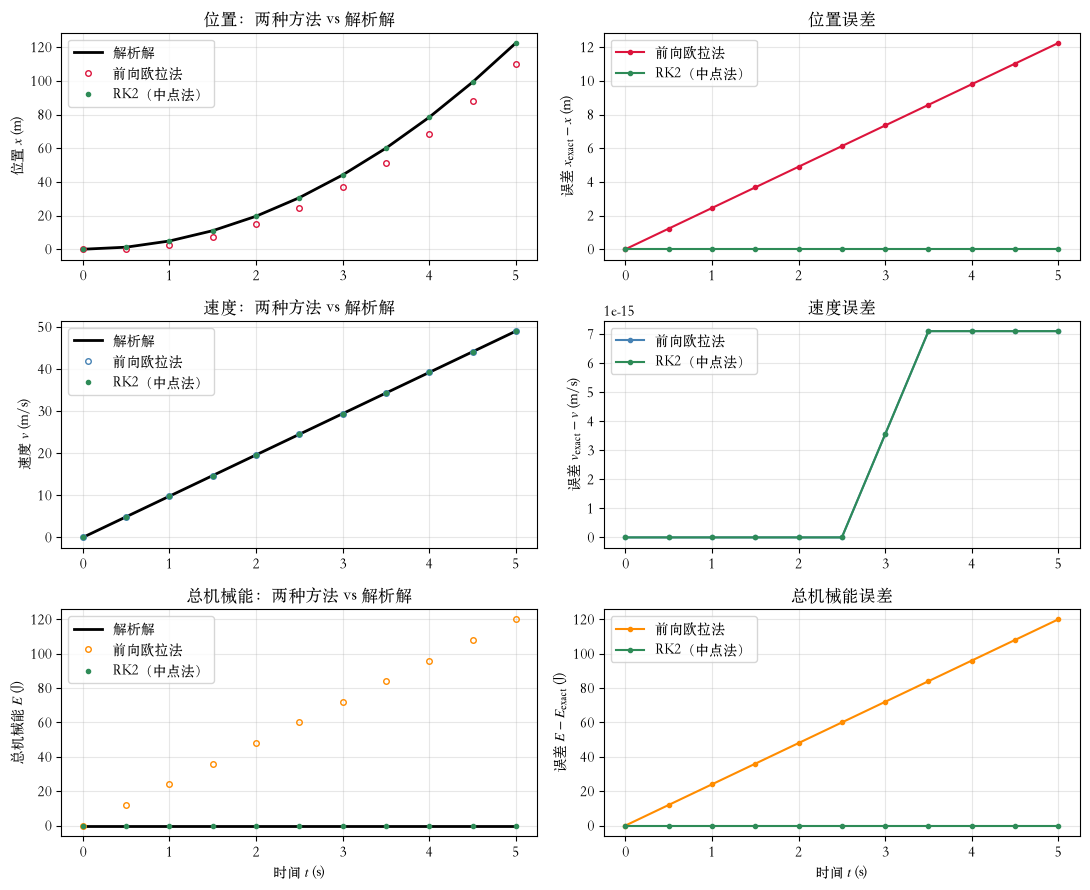

In [3]:
fig, axs = plt.subplots(3, 2, figsize=(11, 9))

# 左列：数值解 vs 解析解（两种方法）
ax = axs[0, 0]
ax.plot(t, x_exact, 'k-', lw=2, label='解析解')
ax.plot(t, x_euler, 'o', ms=4, mfc='none', color='crimson', label='前向欧拉法')
ax.plot(t, x_rk2, '.', ms=6, color='seagreen', label='RK2（中点法）')
ax.set_ylabel('位置 $x$ (m)')
ax.set_title('位置：两种方法 vs 解析解')
ax.legend()
ax.grid(alpha=0.3)

ax = axs[1, 0]
ax.plot(t, v_exact, 'k-', lw=2, label='解析解')
ax.plot(t, v_euler, 'o', ms=4, mfc='none', color='steelblue', label='前向欧拉法')
ax.plot(t, v_rk2, '.', ms=6, color='seagreen', label='RK2（中点法）')
ax.set_ylabel('速度 $v$ (m/s)')
ax.set_title('速度：两种方法 vs 解析解')
ax.legend()
ax.grid(alpha=0.3)

ax = axs[2, 0]
ax.plot(t, E_exact0, 'k-', lw=2, label='解析解')
ax.plot(t, E_euler, 'o', ms=4, mfc='none', color='darkorange', label='前向欧拉法')
ax.plot(t, E_rk2, '.', ms=6, color='seagreen', label='RK2（中点法）')
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('总机械能 $E$ (J)')
ax.set_title('总机械能：两种方法 vs 解析解')
ax.legend()
ax.grid(alpha=0.3)

# 右列：对应的误差（欧拉为系统误差，RK2 为机器精度噪声）
ax = axs[0, 1]
ax.plot(t, x_exact - x_euler, '.-', color='crimson', label='前向欧拉法')
ax.plot(t, x_exact - x_rk2, '.-', color='seagreen', label='RK2（中点法）')
ax.set_ylabel('误差 $x_{\\mathrm{exact}} - x$ (m)')
ax.set_title('位置误差')
ax.legend()
ax.grid(alpha=0.3)

ax = axs[1, 1]
ax.plot(t, v_exact - v_euler, '.-', color='steelblue', label='前向欧拉法')
ax.plot(t, v_exact - v_rk2, '.-', color='seagreen', label='RK2（中点法）')
ax.set_ylabel('误差 $v_{\\mathrm{exact}} - v$ (m/s)')
ax.set_title('速度误差')
ax.legend()
ax.grid(alpha=0.3)

ax = axs[2, 1]
ax.plot(t, E_euler - E_exact0, '.-', color='darkorange', label='前向欧拉法')
ax.plot(t, E_rk2 - E_exact0, '.-', color='seagreen', label='RK2（中点法）')
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('误差 $E - E_{\\mathrm{exact}}$ (J)')
ax.set_title('总机械能误差')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/3_free_fall_rk2_main.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

**对照预测 1–3**：

- **速度更新**：两种方法逐点相同——对恒定加速度，$v_{n+1} = v_n + h\,g$ 本来就精确。两种方法的差别全部集中在位置更新。
- **位置与速度**：RK2 与解析解之差在 $10^{-15}$ 量级——这是浮点舍入的**机器精度**，不是方法误差。RK2 在此精确重演了匀变速运动：中点速度 $v_n + \tfrac{h}{2} g$ 恰为区间上的**平均速度** $\bar v = \bigl[x(t_n + h) - x(t_n)\bigr] / h$。
- **能量**：欧拉的能量漂移随 $t$ 线性增长（前向欧拉法的结构性缺陷）；RK2 的 $E_n$ 停在机器精度水平——短时间内，能量守恒在舍入意义下保持得很好。
- **预测 3 的答案**：步长减半对 RK2 已"无从减起"——方法误差早降为零，再减步长只是换一批同水平的舍入噪声。

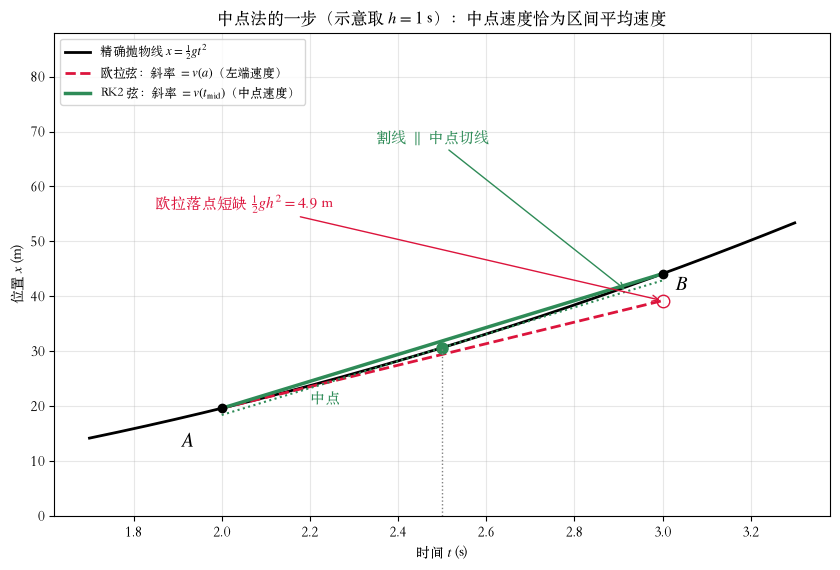

In [4]:
# 中点法的一步：抛物线的割线斜率恰为中点切线斜率（示意取 h = 1 s 放大差别）
g_demo, h_demo = g, 1.0
a = 2.0                       # 时间区间 [a, a + h_demo]
b = a + h_demo
tm = a + 0.5 * h_demo         # 中点

x_demo = lambda tt: 0.5 * g_demo * tt**2
v_demo = lambda tt: g_demo * tt

x_euler_land = x_demo(a) + h_demo * v_demo(a)   # 欧拉落点（用左端速度）
x_rk2_land   = x_demo(a) + h_demo * v_demo(tm)  # RK2 落点（用中点速度）

tt = np.linspace(1.7, 3.3, 301)

fig, ax = plt.subplots(figsize=(8.5, 5.8))
ax.plot(tt, x_demo(tt), 'k-', lw=2, label='精确抛物线 $x = \\frac{1}{2} g t^2$')

# 欧拉弦：斜率 = 左端点速度
ax.plot([a, b], [x_demo(a), x_euler_land], '--', color='crimson', lw=2,
        label='欧拉弦：斜率 $= v(a)$（左端速度）')
ax.plot(b, x_euler_land, 'o', mfc='none', color='crimson', ms=9)
ax.annotate(f'欧拉落点短缺 $\\frac{{1}}{{2}} g h^2 = {0.5 * g_demo * h_demo**2:.1f}$ m',
            xy=(b, x_euler_land), xytext=(1.85, 56), color='crimson', fontsize=11,
            arrowprops=dict(arrowstyle='->', color='crimson'))

# RK2 中点弦：斜率 = 中点速度 = 区间平均速度
ax.plot([a, b], [x_demo(a), x_rk2_land], '-', color='seagreen', lw=2.5,
        label='RK2 弦：斜率 $= v(t_{\\mathrm{mid}})$（中点速度）')
ax.plot(tm, x_demo(tm), 'o', color='seagreen', ms=8)
ax.plot([tm, tm], [0, x_demo(tm)], ':', color='gray', lw=1)

# 中点切线（与 RK2 弦平行，仅示意斜率）
t_tan = np.linspace(tm - 0.5, tm + 0.5, 10)
ax.plot(t_tan, x_demo(tm) + v_demo(tm) * (t_tan - tm), ':', color='seagreen', lw=1.5)

ax.plot([a, b], [x_demo(a), x_demo(b)], '.', color='black', ms=12)
ax.annotate('$A$', xy=(a, x_demo(a)), xytext=(a - 0.09, x_demo(a) - 7), fontsize=14)
ax.annotate('$B$', xy=(b, x_demo(b)), xytext=(b + 0.03, x_demo(b) - 3), fontsize=14)
ax.annotate('中点', xy=(tm, x_demo(tm)), xytext=(tm - 0.30, x_demo(tm) - 10),
            color='seagreen', fontsize=11)
ax.annotate('割线 $\\parallel$ 中点切线',
            xy=(tm + 0.42, x_demo(tm) + v_demo(tm) * 0.42),
            xytext=(2.35, 68), color='seagreen', fontsize=11,
            arrowprops=dict(arrowstyle='->', color='seagreen'))

ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('位置 $x$ (m)')
ax.set_title('中点法的一步（示意取 $h = 1$ s）：中点速度恰为区间平均速度')
ax.set_ylim(0, 88)
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig('outputs/3_free_fall_rk2_midpoint.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

## 为什么 RK2 在这里恰好精确

- **中点速度 = 区间平均速度**：自由落体的 $v(t) = v_0 + g\,t$ 随 $t$ **线性**变化，区间 $[t_n,\, t_n + h]$ 上的平均速度既是两端速度的平均，也恰是中点时刻的速度：

  $$
  \bar v = \frac{v(t_n) + v(t_n + h)}{2} = v\!\left(t_n + \tfrac{h}{2}\right)
  $$

  欧拉法用左端速度，相当于把每步位移算成"左矩形"面积，每步少算 $\tfrac{1}{2} g h^2$；中点法则相当于精确积分。
- **几何图像**：抛物线有个特殊性质——**区间上割线的斜率恰等于中点处切线的斜率**。RK2 用中点斜率走整步，弦的落点自然正好落在曲线上（上图）。
- **能量守恒**：每一步都精确落在抛物线轨道上，数值状态就是解析状态（只差机器舍入），总机械能 $E = \tfrac{1}{2}mv^2 - mgx$ 随之严格守恒。

**必须强调**：这种"分毫不差"是**常力问题的特殊恩惠**。一旦力随时间或状态变化（如简谐振子 $\ddot x = -\omega_0^2 x$、空气阻力），中点速度就不再是平均速度，RK2 退回"二阶精度"——仍比欧拉（一阶）高阶，但不再精确。方法的**精度阶**是一般保证；能否"恰好精确"，取决于问题本身。

## 速度相空间：两种方法的轨道对比

用前向欧拉法时，数值轨道会向等能线的哪一侧穿越？现在把两种方法的数值轨道画进速度相空间 $(x, v)$——等能线 $E = \tfrac{1}{2}mv^2 - mgx = $ const 仍是那族向右开口的抛物线。运行后观察：两种方法各沿（或穿越）哪些等能线？

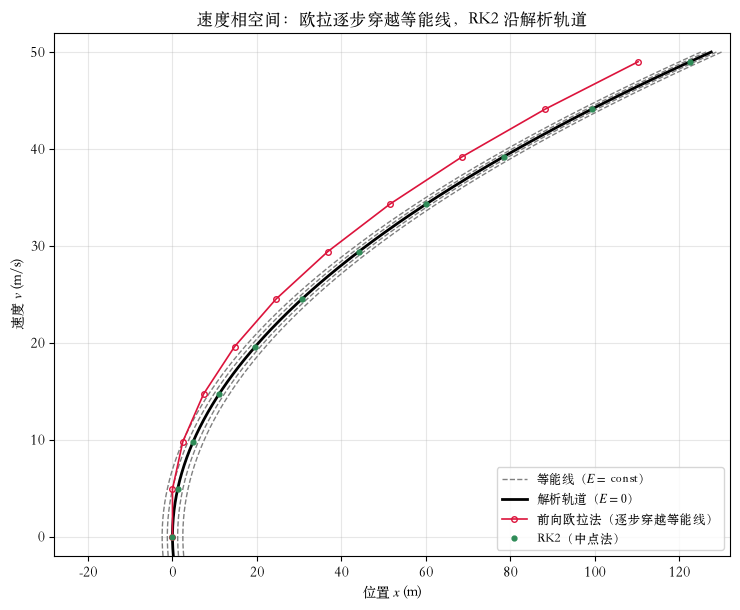

In [5]:
# 速度相空间：等能线为向右开口的抛物线 x = v^2/(2g) - E/(mg)
# E > 0 的等能线整体向左平移 -E/(mg)
v_line = np.linspace(-2.0, 50.0, 401)

fig, ax = plt.subplots(figsize=(7.5, 6.2))

labeled = False
for dE in (-24.0, -12.0, 12.0, 24.0):
    ax.plot(v_line**2 / (2 * g) + dE / g, v_line, '--', color='gray', lw=1.0,
            label='等能线（$E = $ const）' if not labeled else None)
    labeled = True
ax.plot(v_line**2 / (2 * g), v_line, 'k-', lw=2, label='解析轨道（$E = 0$）')

ax.plot(x_euler, v_euler, 'o-', ms=4, mfc='none', color='crimson', lw=1.2,
        label='前向欧拉法（逐步穿越等能线）')
ax.plot(x_rk2, v_rk2, '.', ms=7, color='seagreen', label='RK2（中点法）')

ax.set_xlabel('位置 $x$ (m)')
ax.set_ylabel('速度 $v$ (m/s)')
ax.set_xlim(-28, 132)
ax.set_ylim(-2, 52)
ax.set_title('速度相空间：欧拉逐步穿越等能线，RK2 沿解析轨道')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig('outputs/3_free_fall_rk2_phase.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

## 收敛性分析：两种方法同台对比

用一系列从粗到细的步长重复计算，把两种方法的**末位置误差**与**能量漂移**画在同一组对数坐标里。

**先预测，再运行**：欧拉的两条误差曲线在对数坐标中斜率是多少？RK2 的曲线会落在哪里？步长减半时，RK2 的"误差"如何变化？

   h (s)           欧拉末位置误差      减半比         RK2末位置误差         欧拉能量漂移       RK2能量漂移
   0.500        1.2250e+01       --       1.4211e-14     1.2005e+02    2.2737e-13
   0.250        6.1250e+00     2.00       1.4211e-14     6.0025e+01    9.0949e-13
   0.100        2.4500e+00     2.50       2.8422e-14     2.4010e+01    1.8190e-12
   0.050        1.2250e+00     2.00       7.1054e-14     1.2005e+01    1.8190e-12
   0.025        6.1250e-01     2.00       7.1054e-14     6.0025e+00    5.9117e-12
   0.010        2.4500e-01     2.50       3.9790e-13     2.4010e+00    1.0459e-11


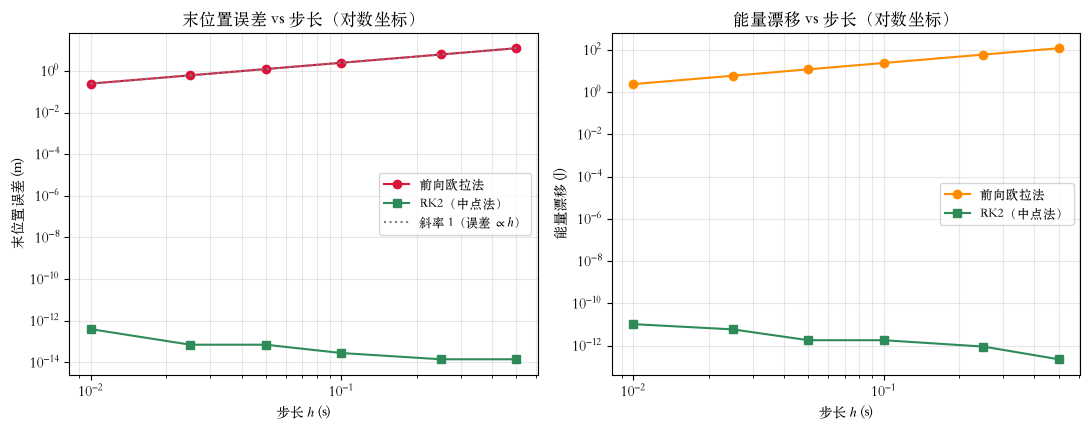

In [6]:
h_list = [0.5, 0.25, 0.1, 0.05, 0.025, 0.01]

x_err_e, x_err_r = [], []
E_drift_e, E_drift_r = [], []

print(f'{"h (s)":>8}{"欧拉末位置误差":>18}{"减半比":>9}{"RK2末位置误差":>17}{"欧拉能量漂移":>15}{"RK2能量漂移":>14}')
for h_i in h_list:
    n_i = int(t_end / h_i)
    _, xe_i, ve_i = forward_euler_free_fall(x0, v0, g, h_i, n_i)
    _, xr_i, vr_i = rk2_midpoint_free_fall(x0, v0, g, h_i, n_i)

    err_e = abs(xe_i[-1] - x_exact[-1])
    err_r = abs(xr_i[-1] - x_exact[-1])
    drift_e = abs(0.5 * m * ve_i[-1]**2 - m * g * xe_i[-1] - E_exact0[-1])
    drift_r = abs(0.5 * m * vr_i[-1]**2 - m * g * xr_i[-1] - E_exact0[-1])

    x_err_e.append(err_e); x_err_r.append(err_r)
    E_drift_e.append(drift_e); E_drift_r.append(drift_r)

    ratio = f'{x_err_e[-2] / err_e:.2f}' if len(x_err_e) > 1 else '--'
    print(f'{h_i:>8.3f}{err_e:>18.4e}{ratio:>9}{err_r:>17.4e}{drift_e:>15.4e}{drift_r:>14.4e}')

# 防 log(0)：RK2 的误差可能小到 0（机器舍入的结果）
floor = 1e-18
h_arr = np.array(h_list)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))

ax1.loglog(h_arr, np.maximum(x_err_e, floor), 'o-', color='crimson', label='前向欧拉法')
ax1.loglog(h_arr, np.maximum(x_err_r, floor), 's-', color='seagreen', label='RK2（中点法）')
ax1.loglog(h_arr, x_err_e[0] * h_arr / h_arr[0], ':', color='gray',
            label='斜率 1（误差 $\\propto h$）')
ax1.set_xlabel('步长 $h$ (s)')
ax1.set_ylabel('末位置误差 (m)')
ax1.set_title('末位置误差 vs 步长（对数坐标）')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3, which='both')

ax2.loglog(h_arr, np.maximum(E_drift_e, floor), 'o-', color='darkorange', label='前向欧拉法')
ax2.loglog(h_arr, np.maximum(E_drift_r, floor), 's-', color='seagreen', label='RK2（中点法）')
ax2.set_xlabel('步长 $h$ (s)')
ax2.set_ylabel('能量漂移 (J)')
ax2.set_title('能量漂移 vs 步长（对数坐标）')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, which='both')

plt.tight_layout()
fig.savefig('outputs/3_free_fall_rk2_convergence.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

**读图**：欧拉的末位置误差与能量漂移都沿**斜率 1** 的直线下降（误差 $\propto h$，一阶方法）；RK2 的两条曲线从一开始就贴在 $10^{-15} \sim 10^{-12}$ 的机器精度平台上——没有斜率可量，减半步长只是换一批同水平的舍入噪声。与运行前的预测一致吗？

## 长时间模拟：机器精度不等于守恒

前面的模拟只跑了 5 秒。现在把时间拉长四个数量级——到 $t = 5\times 10^4$ s（约 14 小时），步长仍取 $h = 0.5$ s（$10^5$ 步）。

**先预测，再运行**：

1. RK2 的能量漂移会一直停在 $10^{-13}$ J 吗？若不会，它由什么决定、大致怎样增长？
2. 减小步长 $h$ 能压住这种漂移吗？

     t (s)        欧拉能量漂移 (J)       RK2能量漂移 (J)
         5         1.200e+02        -2.274e-13
        50         1.200e+03        -3.636e-10
       500         1.200e+04        -1.229e-07
      5000         1.201e+05         3.195e-04
     50000         1.201e+06         3.631e-01


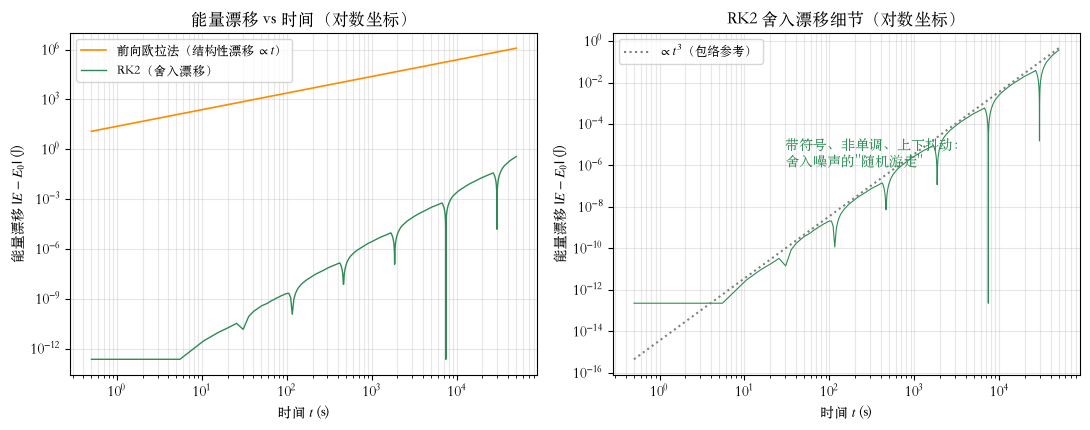

In [7]:
t_long = 5.0e4                      # 总时间 (s)：比前面拉长四个数量级
n_long = int(t_long / h)            # 1e5 步

t_L, x_er, v_er = forward_euler_free_fall(x0, v0, g, h, n_long)
t_L, x_rr, v_rr = rk2_midpoint_free_fall(x0, v0, g, h, n_long)

E_er = 0.5 * m * v_er**2 - m * g * x_er
E_rr = 0.5 * m * v_rr**2 - m * g * x_rr
drift_er = E_er - E_exact0[-1]
drift_rr = E_rr - E_exact0[-1]

print(f'{"t (s)":>10}{"欧拉能量漂移 (J)":>18}{"RK2能量漂移 (J)":>18}')
for t_show in (5, 50, 500, 5000, 50000):
    k = int(t_show / h)
    print(f'{t_show:>10.0f}{drift_er[k]:>18.3e}{drift_rr[k]:>18.3e}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
idx = slice(1, None, 10)            # 抽稀作图（1e5 个点太密）

# (a) 两方法同轴对比（对数坐标）
ax1.loglog(t_L[idx], np.abs(drift_er[idx]), lw=1.2, color='darkorange',
           label='前向欧拉法（结构性漂移 $\\propto t$）')
ax1.loglog(t_L[idx], np.maximum(np.abs(drift_rr[idx]), 1e-17), lw=1.0,
           color='seagreen', label='RK2（舍入漂移）')
ax1.set_xlabel('时间 $t$ (s)')
ax1.set_ylabel('能量漂移 $|E - E_0|$ (J)')
ax1.set_title('能量漂移 vs 时间（对数坐标）')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3, which='both')

# (b) RK2 舍入漂移的细节：噪声式增长，包络按 t^3 量级抬升
ax2.loglog(t_L[idx], np.maximum(np.abs(drift_rr[idx]), 1e-17), '-', lw=0.8,
           color='seagreen')
ax2.loglog(t_L[idx], 4.5e-13 * (t_L[idx] / 5.0)**3, ':', color='gray',
           label='$\\propto t^3$（包络参考）')
ax2.annotate('带符号、非单调、上下抖动：\n舍入噪声的"随机游走"',
             xy=(2000, 1e-4), xytext=(30, 1e-6), fontsize=10, color='seagreen')
ax2.set_xlabel('时间 $t$ (s)')
ax2.set_ylabel('能量漂移 $|E - E_0|$ (J)')
ax2.set_title('RK2 舍入漂移细节（对数坐标）')
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(alpha=0.3, which='both')

plt.tight_layout()
fig.savefig('outputs/3_free_fall_rk2_long.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

**读图**：

- RK2 的能量漂移**并没有**停在 $10^{-13}$ J：它随时间无界增长，到 $t = 5\times 10^4$ s 时已达 $0.36$ J——不过同一时刻欧拉的结构性漂移是 $1.2\times 10^6$ J，两者相差近七个数量级。
- 两种漂移的**机制不同**。欧拉：方法误差，每步系统性地漏算 $\tfrac{1}{2} g h^2$ 对应的能量，漂移 $\propto h\,t$（左图直线，斜率 1）。RK2：浮点**舍入**误差——每步加法的舍入约为机器精度 $\varepsilon_{\mathrm{mach}}$ 乘以数值本身的大小，而 $x \sim \tfrac{1}{2} g t^2$ 越来越大、累积的步数 $t/h$ 也越来越多，包络大致按 $t^3$ 量级抬升（右图参考线）。
- 右图曲线带符号、非单调、上下抖动——舍入噪声"随机游走"的直接证据，与欧拉平滑的单向漂移形成鲜明对比。
- 预测 2 有了答案：减小 $h$ 对舍入漂移**无济于事**（步数反而更多、累积更久），它只能压住欧拉那类方法误差。**在浮点运算的世界里，没有哪种数值方法能严格守恒能量**——守恒只能守恒到舍入水平。一句话：机器精度不是零，时间够长，它也会长大。

## 结论与思考

**先对照引言的三个预测**（速度更新是否相同？与解析解的关系、能量是否守恒？步长减半的效果？），再记住下面几条：

- **RK2 = 欧拉 + 中点斜率**：每步多算一次右端（半步预估），把更新斜率从"区间左端值"升级为"区间代表值"，精度从一阶升到二阶。
- **自由落体中 RK2 恰好精确**：常力 $\Rightarrow$ $v(t)$ 线性 $\Rightarrow$ 中点速度 = 区间平均速度 $\Rightarrow$ 每步位置更新 $x_n + h\,v_n + \tfrac{1}{2} g h^2$ 与匀变速位移公式逐项相同。位置、速度、能量全部精确到机器精度——但机器精度不是零，时间够长时舍入漂移照样无界增长（见上一节）。
- **欧拉缺失的 $\tfrac{1}{2} g h^2$** 正是 RK2 中点弦补回的那一项——欧拉法的位置滞后与能量漂移在这里一并消失。
- **精确是巧合，二阶是保证**：力随时间/状态变化时，RK2 只保证误差 $\mathcal{O}(h^2)$；"恰好精确"只属于自由落体这类"简单问题"。

**思考**：

1. 把 `rk2_midpoint_free_fall` 稍加改造，用于简谐振子 $\ddot x = -\omega_0^2 x$（力随状态变化）：RK2 还精确吗？能量还守恒吗？动手试试。
2. RK2 还有另一种常见形式——**梯形法**（Heun）：$\boldsymbol k_2$ 取区间**端点**的斜率，$\boldsymbol y_{n+1} = \boldsymbol y_n + \tfrac{h}{2}(\boldsymbol k_1 + \boldsymbol k_2)$。它在自由落体中同样精确——为什么？（提示：$v$ 线性时，中点速度与两端平均速度相等。）对一般问题，两种形式的结果还相同吗？
3. 若加入空气阻力（加速度 $g - \gamma v$），中点速度还是区间平均速度吗？猜一猜 RK2 误差随 $h$ 的阶数，再仿照本例的收敛性代码验证。
4. 把长时间模拟的步长改为 $h = 0.05$ s 重跑上一节代码：RK2 的舍入漂移变大还是变小？这与"减小步长能减小误差"的直觉矛盾吗？